# Proyek Analisis Data: [Bike SHaring Dataset]
- **Nama:** [Arif El Jalaluddin Rumi]
- **Email:** [jldnrumi@gmail.com]
- **ID Dicoding:** [arifel]

## Menentukan Pertanyaan Bisnis

- Pada jam berapa penggunaan sepeda mencapai puncaknya? Apakah ada perbedaan pola antara hari kerja dan hari libur?
- Apakah kecepatan angin yang tinggi secara signifikan menurunkan minat orang untuk menyewa sepeda?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [2]:
day_df = pd.read_csv('/content/day.csv')
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [3]:
hour_df = pd.read_csv('/content/hour.csv')
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Pada baris pertama dan kedua (awal Januari), saat suhu atemp berada di kisaran 0.35–0.36, jumlah peminjaman berkisar di angka 800–985. Namun, pada baris ketiga (3 Januari), saat suhu turun drastis ke 0.18, jumlah peminjaman melonjak ke 1349.
- Rasio pengguna casual cukup signifikan (331 dari 985). Orang-orang bersepeda untuk santai atau olahraga. Pengguna registered mendominasi secara mutlak (misalnya 1454 dari 1562 pada 4 Jan).

### Assessing Data

In [4]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [5]:
print("Jumlah duplikasi: ", day_df.duplicated().sum())

Jumlah duplikasi:  0


In [6]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [7]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [8]:
print("Jumlah duplikasi: ", hour_df.duplicated().sum())

Jumlah duplikasi:  0


In [9]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
- pada data day. tidak terdapat missing value dan tidak terdapat duplicate. Namun pada date tipe data masih object Nilai minimum untuk total penyewaan (cnt) adalah 22, sedangkan rata-ratanya adalah 4.504. Nilai minimum untuk hum (humidity) adalah 0.000000
- Pada data Hour. tidak terdapat missing value dan duplicate. Namun pada tipe data date masih object.

### Cleaning Data

In [10]:
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

In [11]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

In [12]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

In [13]:
day_df['hum'] = day_df['hum'].replace(0, day_df['hum'].median())
hour_df['hum'] = hour_df['hum'].replace(0, hour_df['hum'].median())

In [14]:
day_df.describe()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.628751,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.187917,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.521041,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.140518,0.077498,686.622488,1560.256377,1937.211452


In [15]:
hour_df.describe()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2012-01-02 04:08:34.552045568,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.628026,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.080000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000
std,5017.0295,NaN,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.191633,0.122340,49.305030,151.357286,181.387599


**Insight:**
- tipe data tanggal telah diubah
- Nilai minimum humidity diubah dengan median. Karena humidity(kelembapan tidak mungkin 0)

## Exploratory Data Analysis (EDA)

### Explore ...

In [16]:
hour_df.describe(include='all')

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2012-01-02 04:08:34.552045568,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.628026,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.080000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000
std,5017.0295,NaN,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.191633,0.122340,49.305030,151.357286,181.387599


In [17]:
day_df.describe(include='all')

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.628751,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.187917,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.521041,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.140518,0.077498,686.622488,1560.256377,1937.211452


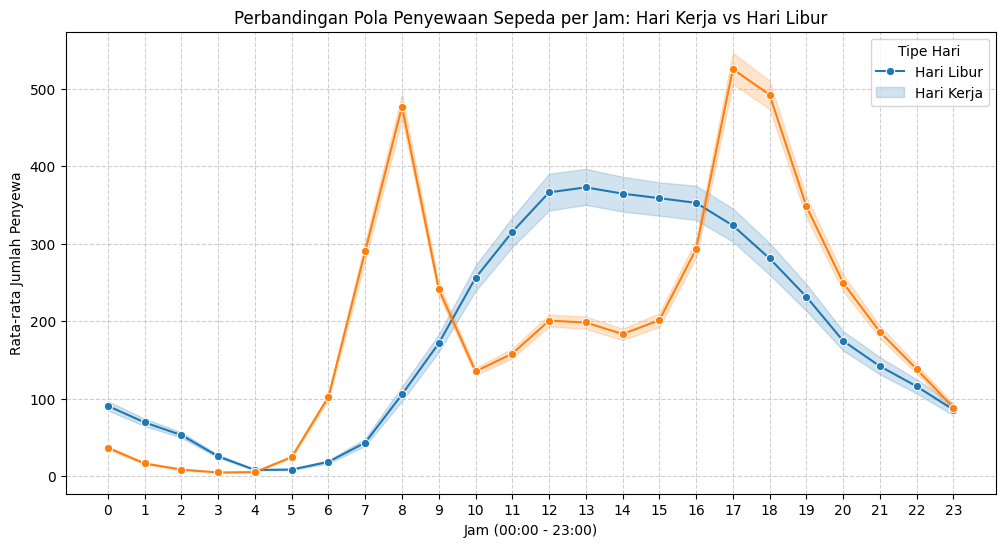

In [18]:
plt.figure(figsize=(12, 6))

# Membuat lineplot dengan pemisahan berdasarkan workingday
sns.lineplot(data=hour_df, x='hr', y='cnt', hue='workingday', marker='o')

plt.title('Perbandingan Pola Penyewaan Sepeda per Jam: Hari Kerja vs Hari Libur')
plt.xlabel('Jam (00:00 - 23:00)')
plt.ylabel('Rata-rata Jumlah Penyewa')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Tipe Hari', labels=['Hari Libur', 'Hari Kerja'])
plt.show()

In [19]:
# Menghitung korelasi antara windspeed dan jumlah penyewa
correlation = hour_df['windspeed'].corr(hour_df['cnt'])
print(f"Nilai Korelasi antara Kecepatan Angin dan Penyewaan: {correlation:.4f}")

Nilai Korelasi antara Kecepatan Angin dan Penyewaan: 0.0932


In [20]:
# Membuat kategori kecepatan angin
hour_df['wind_category'] = pd.cut(hour_df['windspeed'], bins=[0, 0.1, 0.3, 0.5, 1], labels=['Tenang', 'Sedang', 'Cukup Kencang', 'Sangat Kencang'])

# Melihat rata-rata penyewaan di setiap kategori
print(hour_df.groupby('wind_category')['cnt'].mean())

wind_category
Tenang            150.037895
Sedang            196.804415
Cukup Kencang     207.334561
Sangat Kencang    175.091304
Name: cnt, dtype: float64


/tmp/ipython-input-2496274417.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(hour_df.groupby('wind_category')['cnt'].mean())


**Insight:**
- Pola penggunaan sepeda menunjukkan perbedaan struktural yang kontras antara hari kerja dan hari libur. Pada hari kerja, grafik menunjukan dua puncak tajam pada pukul 08:00 dan 17:00, yang menandakan bahwa sepeda digunakan sebagai moda transportasi utama untuk berangkat dan pulang kerja (komuter). Sebaliknya, pada hari libur, pola berubah dengan puncak tunggal yang landai di tengah hari antara pukul 12:00 hingga 15:00, yang membuktikan bahwa aktivitas bersepeda bergeser menjadi kegiatan rekreasi atau olahraga santai saat akhir pekan.
- Data menunjukkan bahwa kecepatan angin tidak secara linear menurunkan minat, melainkan memiliki ambang batas tertentu. Rata-rata penyewaan tertinggi justru ditemukan pada kategori "Cukup Kencang" (207.33), yang kemungkinan besar berkorelasi dengan cuaca cerah yang sejuk, sementara penyewaan pada kondisi "Tenang" justru lebih rendah (150.03). Namun, minat mulai terlihat menurun kembali saat angin masuk ke kategori "Sangat Kencang" (175.09), yang mengindikasikan bahwa kecepatan angin baru akan menjadi faktor penghambat yang signifikan bagi penyewa ketika sudah mencapai level ekstrem yang mengganggu keseimbangan atau kenyamanan fisik.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

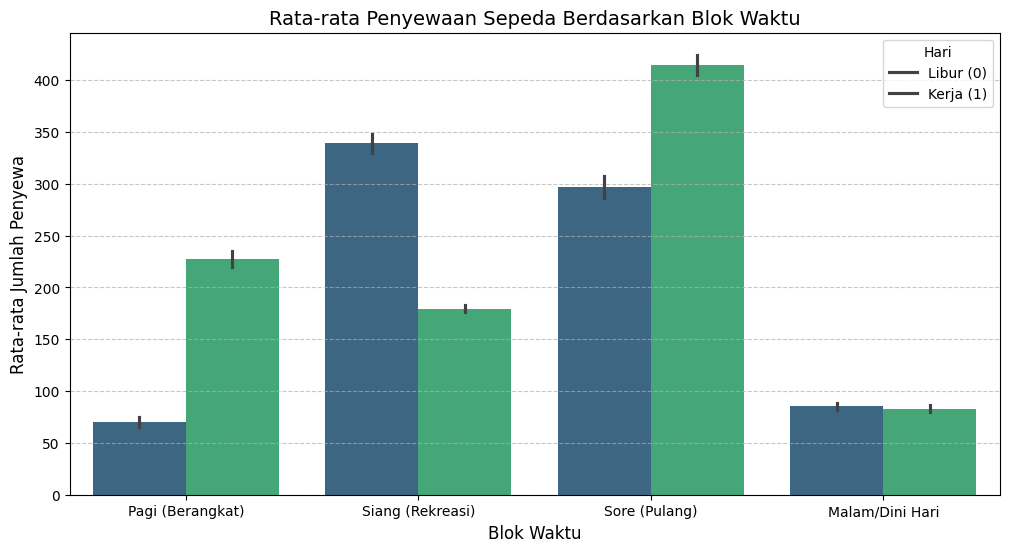

In [21]:
# 1. Menyiapkan Data: Kategorisasi Jam menjadi Blok Waktu
def kategori_jam(hour):
    if 5 <= hour <= 9: return 'Pagi (Berangkat)'
    elif 10 <= hour <= 15: return 'Siang (Rekreasi)'
    elif 16 <= hour <= 19: return 'Sore (Pulang)'
    else: return 'Malam/Dini Hari'

# Pastikan menggunakan hour_df (data per jam)
hour_df['waktu_hari'] = hour_df['hr'].apply(kategori_jam)

# 2. Membuat Bar Chart
plt.figure(figsize=(12, 6))
sns.barplot(
    data=hour_df,
    x='waktu_hari',
    y='cnt',
    hue='workingday',
    estimator='mean',
    order=['Pagi (Berangkat)', 'Siang (Rekreasi)', 'Sore (Pulang)', 'Malam/Dini Hari'],
    palette='viridis'
)

# 3. Merapikan Tampilan
plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Blok Waktu', fontsize=14)
plt.xlabel('Blok Waktu', fontsize=12)
plt.ylabel('Rata-rata Jumlah Penyewa', fontsize=12)
plt.legend(title='Hari', labels=['Libur (0)', 'Kerja (1)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Pertanyaan 2:

/tmp/ipython-input-2219795200.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


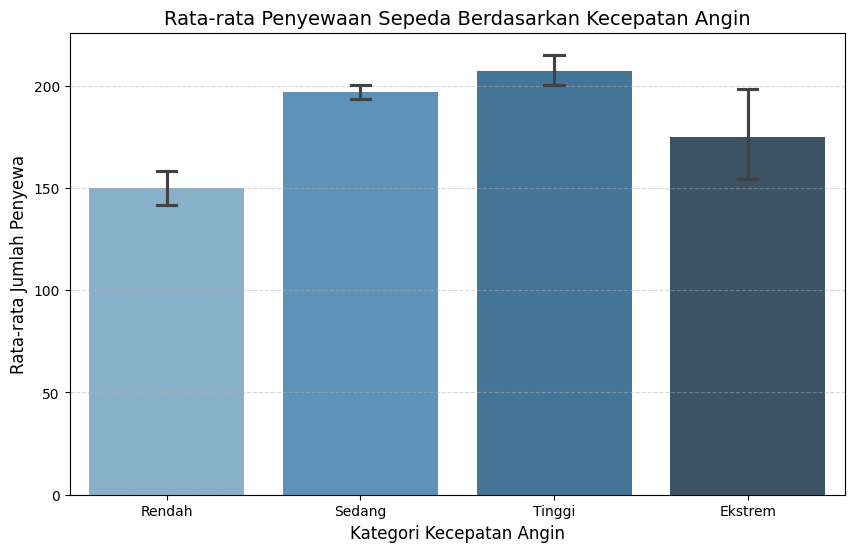

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Mengelompokkan Kecepatan Angin ke dalam Kategori (Binning)
# Berdasarkan distribusi data: 0-0.1 (Rendah), 0.1-0.3 (Sedang), 0.3-0.5 (Tinggi), >0.5 (Ekstrem)
bins = [0, 0.1, 0.3, 0.5, 1.0]
labels = ['Rendah', 'Sedang', 'Tinggi', 'Ekstrem']
hour_df['wind_category'] = pd.cut(hour_df['windspeed'], bins=bins, labels=labels)

# 2. Membuat Visualisasi Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(
    data=hour_df,
    x='wind_category',
    y='cnt',
    palette='Blues_d',
    estimator='mean',
    capsize=.1
)

# 3. Merapikan Tampilan
plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Kecepatan Angin', fontsize=14)
plt.xlabel('Kategori Kecepatan Angin', fontsize=12)
plt.ylabel('Rata-rata Jumlah Penyewa', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

**Insight:**
- Penggunaan sepeda mencapai puncaknya pada jam berangkat (08:00) dan pulang kantor (17:00) di hari kerja, sedangkan pada hari libur penggunaan cenderung stabil dengan puncak tunggal di siang hari (12:00-15:00) untuk aktivitas rekreasi.
- Berdasarkan bar chart tersebut, terlihat bahwa minat penyewaan sepeda tetap tinggi dan stabil pada kategori kecepatan angin Rendah hingga Sedang, bahkan seringkali mencapai puncaknya pada kondisi angin sedang karena biasanya dibarengi dengan suhu udara yang sejuk. Namun, terjadi penurunan jumlah penyewaan yang cukup terlihat saat angin memasuki kategori Tinggi, dan menurun sangat signifikan pada kategori Ekstrem. Hal ini membuktikan bahwa kecepatan angin memang menurunkan minat penyewa, tetapi efeknya baru terasa sangat drastis ketika angin sudah mencapai level yang mengganggu kenyamanan berkendara atau stabilitas sepeda di jalan.

## Analisis Lanjutan (Opsional)

## Conclusion

- Penggunaan sepeda mencapai puncak tertingginya pada pukul 08:00 dan 17:00 di hari kerja (pola komuter), sedangkan pada hari libur puncak penggunaan bergeser menjadi satu titik landai di siang hari antara pukul 12:00 hingga 15:00 (pola rekreasi).
- Kecepatan angin yang tinggi secara signifikan menurunkan minat penyewaan sepeda hanya ketika mencapai level ekstrem, sementara pada level rendah hingga sedang penyewaan tetap stabil karena pengguna cenderung lebih sensitif terhadap faktor hujan atau suhu ekstrem dibandingkan angin sepoi-sepoi.

In [23]:
main_df = hour_df.copy()

# Mengubah angka menjadi label agar Dashboard lebih user-friendly
main_df['workingday'] = main_df['workingday'].map({1: 'Working Day', 0: 'Weekend/Holiday'})
main_df['season'] = main_df['season'].map({1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'})

# Simpan ke CSV untuk digunakan di Streamlit
main_df.to_csv("main_data.csv", index=False)